In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import plotly.io as pio 
pio.renderers.default = "svg" 

In [2]:
raw_df = pd.read_csv("Zomato-Chennai-Dataset.csv")

In [3]:
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

In [4]:
#raw_df.head()
raw_df

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [5]:
raw_df.shape

(12032, 12)

In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [7]:
raw_df.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


In [8]:
wrong_df = raw_df['Top Dishes'] == 'Invalid'
raw_df[wrong_df]

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
72,https://www.zomato.com/chennai/deen-biriyani-a...,Deen Biriyani,"687/7, P.H Road, Aminijikarai, Chennai",Aminijikarai,"['Biryani', ' South Indian', ' North Indian', ...",Invalid,500.0,3.9,460,3.8,18,"['Home Delivery', 'Indoor Seating']"
240,https://www.zomato.com/chennai/smoke-hub-barbe...,Smoke Hub Barbeque,"Old 56, New 163, 1st Floor, Velachery Main Ro...",Velachery,"['BBQ', ' Asian', ' North Indian', ' Desserts'...",Invalid,1500.0,4.3,867,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Serves Halal', 'Gaming Area..."
291,https://www.zomato.com/chennai/nellai-fast-foo...,Nellai Fast Food,"5, P.T Street, Greams Road, Thousand Lights, ...",Thousand Lights,"['Chinese', ' Biryani', ' North Indian']",Invalid,300.0,4.0,366,3.8,24200,"['Breakfast', 'Home Delivery', 'Indoor Seating']"
294,https://www.zomato.com/chennai/hunger-palato-m...,Hunger Palato,"Shop D-2B, Survey 52 & 53, 200 Feet Radial Ro...",Medavakkam,"['Momos', ' Steak', ' Burger']",Invalid,350.0,3.9,128,3.9,44,"['Breakfast', 'Home Delivery', 'Outdoor Seatin..."
436,https://www.zomato.com/chennai/kebablake-stree...,Kebab@Lake Street,"364, TNHB Main Road, Maruthapandiyar Salai, G...",Velachery,"['Kebab', ' Mughlai', ' Chinese', ' Biryani']",Invalid,500.0,4.0,266,3.8,10300,"['Home Delivery', 'Catering Available', 'Free ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [9]:
raw_df = raw_df[~wrong_df]

In [10]:
raw_df

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...,...,...
10964,https://www.zomato.com/chennai/hot-breads-t-nagar,Hot Breads,"147, Ground Floor, Sivagami Square, GN Chetty...",T. Nagar,"['Bakery', ' Fast Food', ' Beverages']","['Choco Truffle', ' Cupcake']",450.0,3.0,47,3.9,22,"['Home Delivery', 'Catering Available', 'Desse..."
10988,https://www.zomato.com/chennai/cookie-man-vada...,Cookie Man,"Ground Floor, Forum Vijaya Mall, Arcot Road, ...","Forum Vijaya Mall, Vadapalani","['Bakery', ' Desserts']",['Macaroon'],140.0,NaN,Does not offer Dining,3.7,96,"['Home Delivery', 'Wheelchair Accessible', 'Ma..."
11035,https://www.zomato.com/chennai/uzo-sandwiches-...,Uzo Sandwiches,"71, Pilayar Koil Street, SRM Nagar, Potheri, ...",Potheri,"['Sandwich', ' Burger', ' Wraps', ' Fast Food'...","['Burgers', ' Chicken Sandwich', ' Pizza Sandw...",300.0,4.0,453,4.1,7093,"['Home Delivery', 'Free Parking', 'Indoor Seat..."
11080,https://www.zomato.com/chennai/the-cake-world-...,The Cake World,"40 A, Velachery Main Road, Velachery, Chennai",Velachery,['Bakery'],['Blackforest Cake'],500.0,3.0,58,3.9,45,"['Home Delivery', 'Indoor Seating', 'Desserts ..."


In [11]:
raw_df.drop(['Zomato URL', 'Address'], axis = 1, inplace=True)

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\3523108143.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [12]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
10964,Hot Breads,T. Nagar,"['Bakery', ' Fast Food', ' Beverages']","['Choco Truffle', ' Cupcake']",450.0,3.0,47,3.9,22,"['Home Delivery', 'Catering Available', 'Desse..."
10988,Cookie Man,"Forum Vijaya Mall, Vadapalani","['Bakery', ' Desserts']",['Macaroon'],140.0,NaN,Does not offer Dining,3.7,96,"['Home Delivery', 'Wheelchair Accessible', 'Ma..."
11035,Uzo Sandwiches,Potheri,"['Sandwich', ' Burger', ' Wraps', ' Fast Food'...","['Burgers', ' Chicken Sandwich', ' Pizza Sandw...",300.0,4.0,453,4.1,7093,"['Home Delivery', 'Free Parking', 'Indoor Seat..."
11080,The Cake World,Velachery,['Bakery'],['Blackforest Cake'],500.0,3.0,58,3.9,45,"['Home Delivery', 'Indoor Seating', 'Desserts ..."


In [13]:
raw_df.isnull().sum()

Name of Restaurant         0
Location                   0
Cuisine                    0
Top Dishes                 0
Price for 2                0
Dining Rating            256
Dining Rating Count        1
Delivery Rating          458
Delivery Rating Count      1
Features                   0
dtype: int64

In [14]:
raw_df.fillna('NA', inplace=True)

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\1020279332.py:1: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\1020279332.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [15]:
raw_df.isnull().sum()

Name of Restaurant       0
Location                 0
Cuisine                  0
Top Dishes               0
Price for 2              0
Dining Rating            0
Dining Rating Count      0
Delivery Rating          0
Delivery Rating Count    0
Features                 0
dtype: int64

In [16]:
raw_df['Dining Rating'].value_counts()

Dining Rating
3.9    267
4.0    256
NA     256
3.8    217
4.1    210
3.7    149
4.2    141
3.6    118
4.3    102
3.5     72
3.4     67
4.4     59
3.1     53
3.3     53
3.0     52
3.2     44
2.9     44
4.5     36
2.8     29
2.7     27
2.6     26
2.5     21
2.4     19
4.6     17
4.7     12
2.3     11
2.2      8
2.1      8
4.9      7
2.0      6
4.8      4
Name: count, dtype: int64

In [17]:
raw_df['Dining Rating'].replace(to_replace=['NA'], value='0', inplace=True)

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\2116547037.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\2116547037.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [18]:
raw_df['Dining Rating']

0        4.3
1        4.4
2        4.3
3        4.0
4        4.2
        ... 
10964    3.0
10988      0
11035    4.0
11080    3.0
11134    3.4
Name: Dining Rating, Length: 2391, dtype: object

In [19]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
10964,Hot Breads,T. Nagar,"['Bakery', ' Fast Food', ' Beverages']","['Choco Truffle', ' Cupcake']",450.0,3.0,47,3.9,22,"['Home Delivery', 'Catering Available', 'Desse..."
10988,Cookie Man,"Forum Vijaya Mall, Vadapalani","['Bakery', ' Desserts']",['Macaroon'],140.0,0,Does not offer Dining,3.7,96,"['Home Delivery', 'Wheelchair Accessible', 'Ma..."
11035,Uzo Sandwiches,Potheri,"['Sandwich', ' Burger', ' Wraps', ' Fast Food'...","['Burgers', ' Chicken Sandwich', ' Pizza Sandw...",300.0,4.0,453,4.1,7093,"['Home Delivery', 'Free Parking', 'Indoor Seat..."
11080,The Cake World,Velachery,['Bakery'],['Blackforest Cake'],500.0,3.0,58,3.9,45,"['Home Delivery', 'Indoor Seating', 'Desserts ..."


In [20]:
raw_df['Dining Rating Count'].replace(to_replace=['Does not offer Dining','NA'], value='0', inplace=True)

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\823050712.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\823050712.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [21]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
10964,Hot Breads,T. Nagar,"['Bakery', ' Fast Food', ' Beverages']","['Choco Truffle', ' Cupcake']",450.0,3.0,47,3.9,22,"['Home Delivery', 'Catering Available', 'Desse..."
10988,Cookie Man,"Forum Vijaya Mall, Vadapalani","['Bakery', ' Desserts']",['Macaroon'],140.0,0,0,3.7,96,"['Home Delivery', 'Wheelchair Accessible', 'Ma..."
11035,Uzo Sandwiches,Potheri,"['Sandwich', ' Burger', ' Wraps', ' Fast Food'...","['Burgers', ' Chicken Sandwich', ' Pizza Sandw...",300.0,4.0,453,4.1,7093,"['Home Delivery', 'Free Parking', 'Indoor Seat..."
11080,The Cake World,Velachery,['Bakery'],['Blackforest Cake'],500.0,3.0,58,3.9,45,"['Home Delivery', 'Indoor Seating', 'Desserts ..."


In [22]:
raw_df['Delivery Rating'].replace(to_replace=['NA'], value='0', inplace=True)

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\1987233054.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\1987233054.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [23]:
raw_df['Delivery Rating Count'].replace(to_replace=['Does not offer Delivery','NA','Not enough Delivery Reviews'], value='0', inplace=True)

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\2962857771.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\2962857771.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [24]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
10964,Hot Breads,T. Nagar,"['Bakery', ' Fast Food', ' Beverages']","['Choco Truffle', ' Cupcake']",450.0,3.0,47,3.9,22,"['Home Delivery', 'Catering Available', 'Desse..."
10988,Cookie Man,"Forum Vijaya Mall, Vadapalani","['Bakery', ' Desserts']",['Macaroon'],140.0,0,0,3.7,96,"['Home Delivery', 'Wheelchair Accessible', 'Ma..."
11035,Uzo Sandwiches,Potheri,"['Sandwich', ' Burger', ' Wraps', ' Fast Food'...","['Burgers', ' Chicken Sandwich', ' Pizza Sandw...",300.0,4.0,453,4.1,7093,"['Home Delivery', 'Free Parking', 'Indoor Seat..."
11080,The Cake World,Velachery,['Bakery'],['Blackforest Cake'],500.0,3.0,58,3.9,45,"['Home Delivery', 'Indoor Seating', 'Desserts ..."


In [25]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2391 entries, 0 to 11134
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     2391 non-null   object 
 1   Location               2391 non-null   object 
 2   Cuisine                2391 non-null   object 
 3   Top Dishes             2391 non-null   object 
 4   Price for 2            2391 non-null   float64
 5   Dining Rating          2391 non-null   object 
 6   Dining Rating Count    2391 non-null   object 
 7   Delivery Rating        2391 non-null   object 
 8   Delivery Rating Count  2391 non-null   object 
 9   Features               2391 non-null   object 
dtypes: float64(1), object(9)
memory usage: 205.5+ KB


In [26]:
raw_df[raw_df['Price for 2'] == 0]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features


In [27]:
raw_df['Price for 2'] = raw_df['Price for 2'].astype('int64')
raw_df['Dining Rating'] = raw_df['Dining Rating'].astype('float64')
raw_df['Dining Rating Count'] = raw_df['Dining Rating Count'].astype('int64')
raw_df['Delivery Rating'] = raw_df['Delivery Rating'].astype('float64')
raw_df['Delivery Rating Count'] = raw_df['Delivery Rating Count'].astype('int64')

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\1686799282.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\1686799282.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\1686799282.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

In [28]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2391 entries, 0 to 11134
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     2391 non-null   object 
 1   Location               2391 non-null   object 
 2   Cuisine                2391 non-null   object 
 3   Top Dishes             2391 non-null   object 
 4   Price for 2            2391 non-null   int64  
 5   Dining Rating          2391 non-null   float64
 6   Dining Rating Count    2391 non-null   int64  
 7   Delivery Rating        2391 non-null   float64
 8   Delivery Rating Count  2391 non-null   int64  
 9   Features               2391 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 205.5+ KB


In [29]:
raw_df.isnull().sum()

Name of Restaurant       0
Location                 0
Cuisine                  0
Top Dishes               0
Price for 2              0
Dining Rating            0
Dining Rating Count      0
Delivery Rating          0
Delivery Rating Count    0
Features                 0
dtype: int64

In [30]:
useless_data = (raw_df['Dining Rating'] == 0.0) | (raw_df['Delivery Rating'] ==0.0)
raw_df[useless_data]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
6,Bai Veetu Kalyanam,Navallur,['Biryani'],"['Bread Halwa', ' Mutton Biryani', ' Brinjal G...",350,0.0,0,4.3,1061,['Home Delivery']
15,Welcome Hotel,Purasavakkam,"['South Indian', ' Desserts', ' Beverages']","['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",300,4.5,1094,0.0,0,"['Breakfast', 'Vegetarian Only', 'Indoor Seati..."
18,Wire Room Bar & Kitchen,"Phoenix Market City, Velachery","['Continental', ' Asian']","['Cocktails', ' Salad', ' Beer', ' Tikka', ' P...",2000,4.1,354,0.0,0,"['Full Bar Available', 'Mall Parking', 'Dance ..."
23,BFF 2.0,RA Puram,"['North Indian', ' Continental', ' Italian']","['Crispy Chicken', ' Cocktails', ' Pizza', ' N...",1500,4.2,464,0.0,0,"['Full Bar Available', 'Indoor Seating', 'Nigh..."
77,Al Dhareeq Beef Biriyani,Kodambakkam,['Biryani'],['Beef Biryani'],300,0.0,0,3.9,19600,['Home Delivery']
...,...,...,...,...,...,...,...,...,...,...
10823,Firangi Bake,Selaiyur,"['Italian', ' Mexican']","['Lasagne', ' Steak', ' Chicken Keema']",400,0.0,0,3.8,822,['Home Delivery']
10826,Firangi Bake,Alwarpet,"['Italian', ' Mexican']","['Lasagne', ' Garlic Bread']",400,0.0,0,3.1,87,"['Breakfast', 'Home Delivery']"
10861,BBQ Ride,Mogappair,['BBQ'],"['Chicken Wrap', ' Drum Sticks']",300,0.0,0,4.3,747,"['Home Delivery', 'Self Service']"
10948,Seena Bhai 1977 Dosa Center,Sowcarpet,['South Indian'],['Cheese Dosa'],200,0.0,0,3.6,244,"['Home Delivery', 'Vegetarian Only']"


In [31]:
raw_df = raw_df[~useless_data]

In [32]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
10867,Perambur Sri Srinivasa,Ambattur,"['North Indian', ' South Indian', ' Chinese', ...","['Fried Rice', ' Panneer Butter Masala']",400,3.7,121,3.9,73,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
10964,Hot Breads,T. Nagar,"['Bakery', ' Fast Food', ' Beverages']","['Choco Truffle', ' Cupcake']",450,3.0,47,3.9,22,"['Home Delivery', 'Catering Available', 'Desse..."
11035,Uzo Sandwiches,Potheri,"['Sandwich', ' Burger', ' Wraps', ' Fast Food'...","['Burgers', ' Chicken Sandwich', ' Pizza Sandw...",300,4.0,453,4.1,7093,"['Home Delivery', 'Free Parking', 'Indoor Seat..."
11080,The Cake World,Velachery,['Bakery'],['Blackforest Cake'],500,3.0,58,3.9,45,"['Home Delivery', 'Indoor Seating', 'Desserts ..."


In [33]:
raw_df[raw_df.duplicated()]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features


In [34]:
raw_df['Cuisine'] = raw_df['Cuisine'].str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace("'", '', regex=False)
raw_df['Top Dishes'] = raw_df['Top Dishes'].str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace("'", '', regex=False)
raw_df['Features'] = raw_df['Features'].str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace("'", '', regex=False)

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\4119197079.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\4119197079.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\SENTHIL-KUMAR-T-H\AppData\Local\Temp\ipykernel_15708\4119197079.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

In [35]:
raw_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500,4.3,1500,4.3,9306,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000,4.4,3059,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500,4.3,1361,4.4,10500,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",Zinger Burger,500,4.0,1101,4.0,11200,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450,4.2,617,4.1,22400,"Home Delivery, Indoor Seating"
...,...,...,...,...,...,...,...,...,...,...
10867,Perambur Sri Srinivasa,Ambattur,"North Indian, South Indian, Chinese, Street...","Fried Rice, Panneer Butter Masala",400,3.7,121,3.9,73,"Breakfast, Home Delivery, Vegetarian Only, Cat..."
10964,Hot Breads,T. Nagar,"Bakery, Fast Food, Beverages","Choco Truffle, Cupcake",450,3.0,47,3.9,22,"Home Delivery, Catering Available, Desserts an..."
11035,Uzo Sandwiches,Potheri,"Sandwich, Burger, Wraps, Fast Food, Beverages","Burgers, Chicken Sandwich, Pizza Sandwich, ...",300,4.0,453,4.1,7093,"Home Delivery, Free Parking, Indoor Seating"
11080,The Cake World,Velachery,Bakery,Blackforest Cake,500,3.0,58,3.9,45,"Home Delivery, Indoor Seating, Desserts and Bakes"


In [36]:
zomato_df = raw_df.copy()

In [37]:
zomato_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500,4.3,1500,4.3,9306,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000,4.4,3059,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500,4.3,1361,4.4,10500,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",Zinger Burger,500,4.0,1101,4.0,11200,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450,4.2,617,4.1,22400,"Home Delivery, Indoor Seating"


## Q1) How many restaurants are in Chennai for each type of Location?

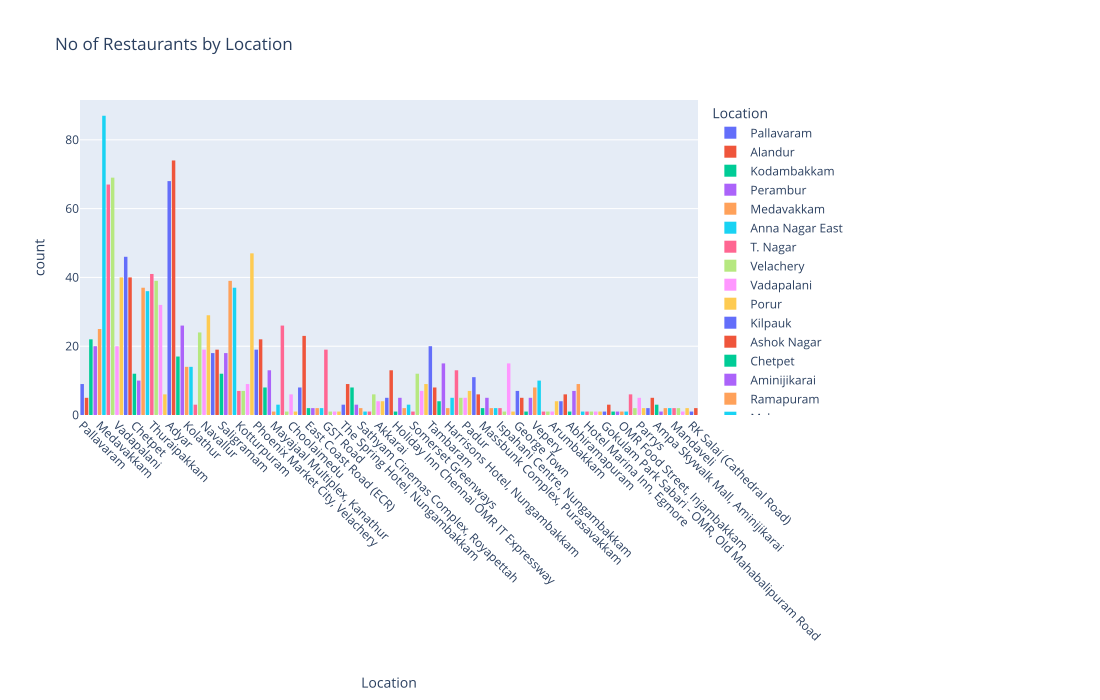

In [39]:
fig = px.histogram(zomato_df, x='Location', color='Location',
 title= 'No of Restaurants by Location',
 labels={'Location':'Location'})
fig.update_xaxes(tickangle=45)
fig.update_layout(
    width=1100,
    height=700)
fig.show()

## Q2) What are the percentage of restaurants by Dining Rating in Chennai?

In [41]:
rating_type_df = zomato_df['Dining Rating'].value_counts().reset_index()
rating_type_df.rename(columns={'index':'Dining Rating', 'Dining Rating':'COUNT OF RESTAURANTS'}, inplace=True)
rating_type_df


,COUNT OF RESTAURANTS,count
0,3.9,222
1,4.0,197
2,3.8,174
3,4.1,160
4,3.7,121
5,4.2,104
6,3.6,93
7,4.3,85
8,3.5,53
9,3.4,51


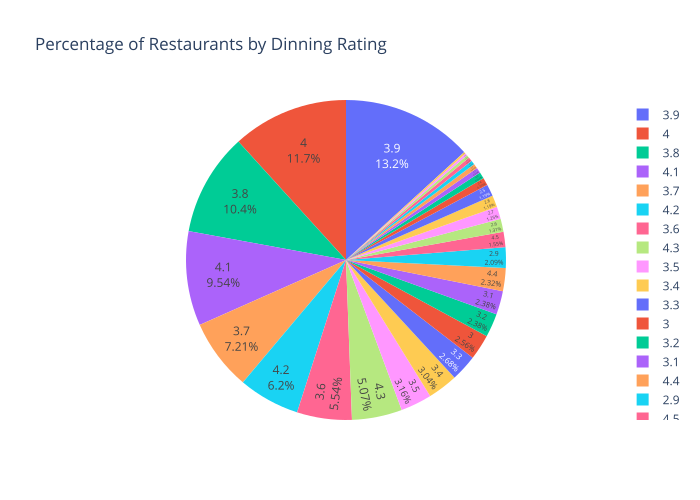

In [42]:
fig = px.pie(rating_type_df, names='COUNT OF RESTAURANTS', values='count', color='COUNT OF RESTAURANTS',
 title='Percentage of Restaurants by Dinning Rating').update_traces(textposition='inside', textinfo='percent+label')
fig.show()

## Q3) Which are the Top 10 highest rated Seafood Restaurant in Chennai?

In [44]:
seafood_df = zomato_df[zomato_df['Cuisine'].str.contains('Biryani')]
seafood_df.sort_values(by='Dining Rating',ascending=False).head(10)

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
116,AlMaza,Anna Nagar East,"Arabian, Mughlai, North Indian, Biryani","Faluda, Rara Gosht, Buttermilk, Naan, Bhar...",1000,4.6,764,4.2,881,"Home Delivery, Indoor Seating, Table booking r..."
9037,Palmshore,Medavakkam,"North Indian, Chinese, Arabian, BBQ, Birya...","Mutton Mandi, Biryani, Brownie, Bbq Fish, ...",1000,4.5,1942,3.8,4379,"Home Delivery, Valet Parking Available, Indoor..."
47,Palmshore,Egmore,"North Indian, Chinese, Arabian, BBQ, Birya...","Mutton Mandi, Fish, Brownie, Sea Food, Bir...",1000,4.4,2162,4.0,9721,"Home Delivery, Indoor Seating, Table booking f..."
9038,Palmshore,Ramapuram,"North Indian, Chinese, Arabian, BBQ, Birya...","Fish, Brownie, Faluda, Murgh Platter, Praw...",1000,4.4,4805,4.1,17300,"Home Delivery, Valet Parking Available, Table ..."
96,Urban Spatula,Anna Nagar West,"Continental, Seafood, Biryani, Italian, No...","Burgers, Pasta, Fish, Fries, Chips, Salad...",800,4.4,794,4.3,911,"Home Delivery, Free Parking, Table booking rec..."
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000,4.4,3059,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
165,Copper Chimney,Gopalapuram,"North Indian, Arabian, Biryani, Mughlai","Paneer Tikka, Naan, Dal Makhani, Rumali Rot...",1200,4.3,906,4.2,1232,"Home Delivery, Indoor Seating, Table reservati..."
241,Sigree Global Grill,"The Spring Hotel, Nungambakkam","North Indian, Kebab, Biryani","Pasta, Pizza, Fish, Jalebi, Chaat, Salad,...",1200,4.3,847,4.2,215,"Home Delivery, Wheelchair Accessible, Full Bar..."
9040,Palmshore,Ashok Nagar,"North Indian, Chinese, Arabian, BBQ, Birya...","Fish, Faluda, Prawn, Brownie, Elaneer Paya...",1000,4.3,4478,4.0,19800,"Home Delivery, Valet Parking Available, Table ..."
126,The Feast,Anna Nagar East,"North Indian, Chinese, Biryani","Bbq Chicken, Biryani, Salad, Mushroom Soup,...",800,4.3,652,3.9,4352,"Home Delivery, Buffet, Free Parking, Indoor Se..."


## Q4) Which is the best North Indian restratunt in Chennai?

In [46]:
foodtruck_df = zomato_df[zomato_df['Cuisine'] == 'North Indian']
foodtruck_df.sort_values(by='Dining Rating',ascending=False).head(2)

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
105,Bhangra,"Mayajaal Multiplex, Kanathur",North Indian,"Butter Chicken, Dal Makhani, Sweet Lassi, K...",800,4.9,2109,4.0,2226,"Breakfast, Home Delivery, Mall Parking, Indoor..."
242,Shyam's Bombay Halwa House,T. Nagar,North Indian,"Paneer Tikka, Paan Ice Cream, Tawa Pulav, B...",600,4.5,798,3.9,63,"Home Delivery, Vegetarian Only, Indoor Seating..."


## Q5) Which places have the highest rated restaurant for each Cuisine in Chennai?

In [48]:
# Assuming restaurants having rating above 4.5
highest_rated_df = zomato_df[zomato_df['Dining Rating'] >= 4.5]
highest_rated_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
24,Eating Circles,Alwarpet,South Indian,"Rose Milk, Neer Dosa, Thatte Idli, Open Mas...",250,4.7,782,4.2,2744,"Breakfast, Home Delivery, Vegetarian Only, Ind..."
37,Shree Mithai,Chetpet,"Mithai, Street Food, Fast Food","Chaat, Badam Milk, Pav Bhaji, Panipuri, Ra...",300,4.6,1085,4.4,18600,"Breakfast, Home Delivery, Vegetarian Only, Fre..."
50,Andhikkadai,Velachery,South Indian,"Coffee, Sweet Kozhukattai, Idli, Pongal, K...",200,4.6,908,4.2,17300,"Breakfast, Home Delivery, Vegetarian Only, Ind..."
57,Brownie Heaven,Royapettah,"Bakery, Desserts, Beverages","Vanilla Ice Cream, Brownie Shake, Filtered C...",350,4.9,842,4.3,2270,"Home Delivery, Indoor Seating, Desserts and Bakes"
59,Mezze,Alwarpet,Middle Eastern,"Baklava, Mezze, Shawarma, Pita Bread, Frie...",700,4.7,1152,4.2,2249,"Home Delivery, Indoor Seating"
62,Amadora Gourmet Ice Cream & Sorbet,Nungambakkam,"Desserts, Ice Cream","Sandwich, Gelato, Chocolate Icecreams, Wate...",500,4.8,1516,4.5,361,"Home Delivery, Outdoor Seating, Desserts and B..."
67,Pumpkin Tales,Alwarpet,"Singaporean, American, European, Continenta...","Pumpkin Soup, Bibimbap, Noodle, Cheesecake,...",1800,4.5,768,4.0,245,"Breakfast, Home Delivery, Indoor Seating, Avai..."
68,Sandy's Chocolate Laboratory,Nungambakkam,"Cafe, Continental, Italian, Desserts","Tiny Chocolate Cake, Hot Chocolate, Sandwich...",1400,4.5,2252,4.3,1973,"Breakfast, Home Delivery, Free Parking, Indoor..."
70,Little Italy,Besant Nagar,"Italian, Mexican, Salad","Pasta, Pizza, Nachos, Tiramisu, Minestrone...",1500,4.7,1349,4.2,1435,"Home Delivery, Vegetarian Only, Valet Parking ..."
75,Fusilli Reasons,Kilpauk,Fast Food,"Nachos, Iced Tea, Garlic Bread, Brownie, S...",400,4.7,3042,4.4,3954,"Home Delivery, Vegetarian Only, Indoor Seating..."


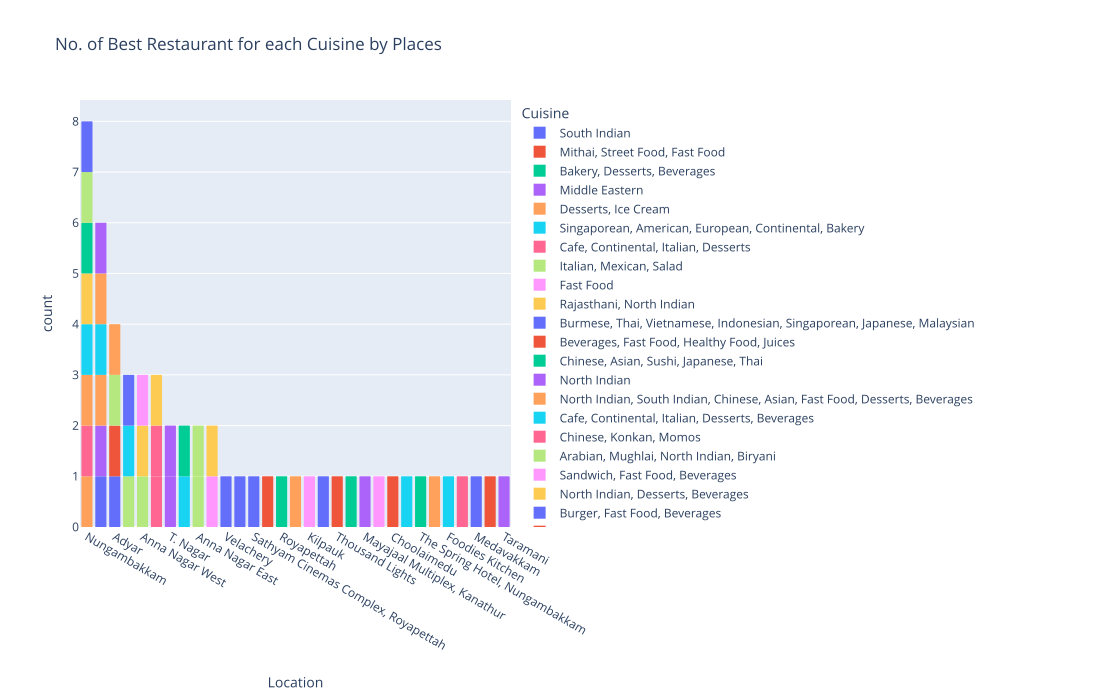

In [49]:
fig = px.histogram(highest_rated_df, x='Location', color='Cuisine',
 title= 'No. of Best Restaurant for each Cuisine by Places').update_xaxes(categoryorder="total descending")
fig.update_layout(
    width=1100,
    height=700)
fig.show()

## Q6) What is the Avg Price Distibution of highest rated restaurant for each Cuisine Type in Chennai

In [51]:
 highest_rated_price_df = highest_rated_df.groupby(by=['Location', 'Cuisine'])['Price for 2'].mean().reset_index() 
highest_rated_price_df.head()

,Location,Cuisine,Price for 2
0,Adyar,"Chinese, Thai",800.0
1,Adyar,Ice Cream,200.0
2,Adyar,"North Indian, Chettinad, Mughlai, Desserts,...",1800.0
3,Adyar,South Indian,500.0
4,Alwarpet,"Desserts, Ice Cream",350.0


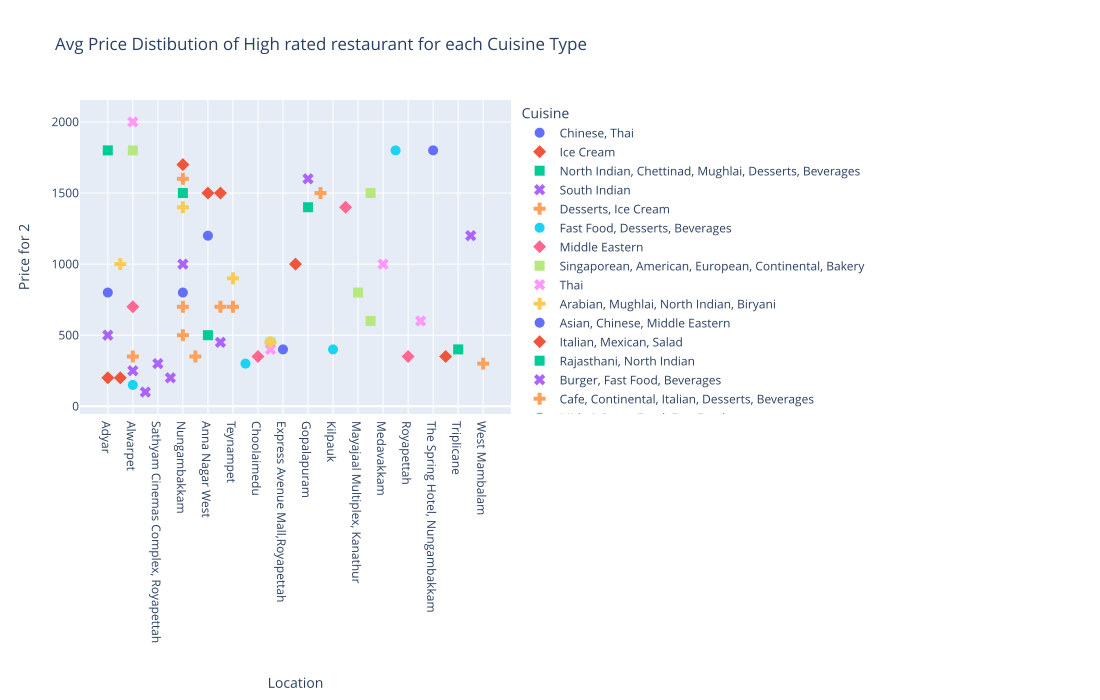

In [52]:
fig = px.scatter(highest_rated_price_df, x="Location", y="Price for 2", color="Cuisine", symbol="Cuisine",  
           title=' Avg Price Distibution of High rated restaurant for each Cuisine Type').update_traces(marker_size=10)
fig.update_layout(
    width=1100,
    height=700)
fig.show()

## Q7) Which areas have a large number of Chinese Restaurant Market?

In [54]:
chinese_df = zomato_df[zomato_df['Cuisine'].str.contains('Chinese')]
chinese_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500,4.3,1361,4.4,10500,"Home Delivery, Indoor Seating"
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450,4.2,617,4.1,22400,"Home Delivery, Indoor Seating"
5,Dine N Fun,Medavakkam,"South Indian, North Indian, Chinese","Chicken Grill, Shawarma, Naan, Chicken Butt...",450,4.1,567,3.8,24700,"Home Delivery, Indoor Seating"
8,Savoury Sea Shell,Anna Nagar East,"Arabian, Chinese, North Indian, Lebanese, ...","Shawarma, Chicken Grill, Brownie, Sea Food,...",1400,4.2,2564,4.1,21700,"Home Delivery, Indoor Seating, Card Upon Deliv..."
9,Sangeetha Veg Restaurant,T. Nagar,"South Indian, North Indian, Chinese, Chetti...","Filtered Coffee, Chaat, Faluda, Masala Dosa...",800,4.4,1578,4.2,39600,"Breakfast, Home Delivery, Vegetarian Only, Ind..."
...,...,...,...,...,...,...,...,...,...,...
10499,The Grand Sweets and Snacks,T. Nagar,"Mithai, Chinese, Street Food, South Indian,...","Chaat, Chips, Kachori, Panipuri, Curd Rice...",450,3.4,76,3.9,80,"Home Delivery, Vegetarian Only, Free Parking, ..."
10501,The Grand Sweets and Snacks,Mylapore,"Mithai, Chinese, Street Food, South Indian,...","Coffee, Chaat, Masala Dosa",450,2.5,45,3.9,59,"Breakfast, Home Delivery, Vegetarian Only, Ind..."
10703,Royal Biriyani,Palavakkam,"North Indian, Chinese","Shawarma, Chicken Grill, Biryani, Tandoori ...",500,3.0,116,4.0,869,"Breakfast, Home Delivery, Indoor Seating"
10704,Royal Biriyani,Thiruvanmiyur,"North Indian, Chinese","Biryani, Brinjal Curry, Rolls, Chicken 65, ...",500,2.6,78,3.9,428,"Home Delivery, Indoor Seating, Catering Availa..."


In [55]:
 chinese_rest_df = chinese_df.groupby(by='Location').agg({'Name of Restaurant' : 'count', 'Price for 2' : 'mean'}).rename(columns= {'Name of Restaurant' : 'COUNT OF RESTAURANTS'})
 chinese_rest_df = chinese_rest_df.sort_values('COUNT OF RESTAURANTS', ascending=False).head(25) 

chinese_rest_df.head() 

,COUNT OF RESTAURANTS,Price for 2
Location,,
Anna Nagar East,38,728.947368
Adyar,28,653.571429
Velachery,27,701.851852
T. Nagar,26,573.076923
Thuraipakkam,23,669.565217


In [56]:
print(chinese_rest_df.columns)

Index(['COUNT OF RESTAURANTS', 'Price for 2'], dtype='object')


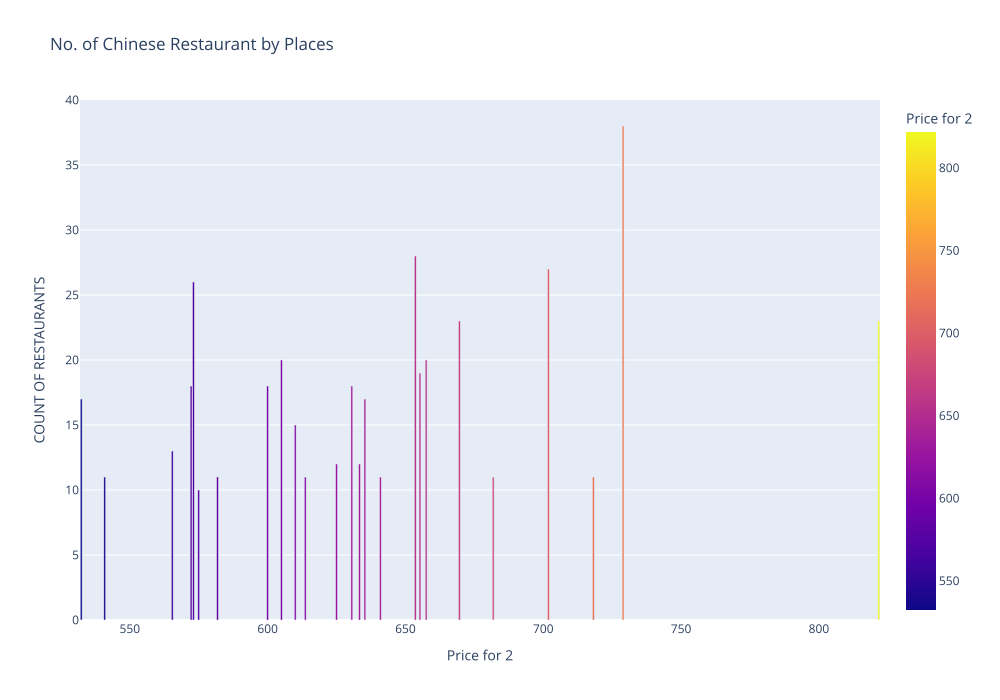

In [57]:
fig = px.bar(chinese_rest_df, x='Price for 2', y='COUNT OF RESTAURANTS', color='Price for 2', title= 'No. of Chinese Restaurant by Places')
fig.update_layout(
    width=1000,
    height=700)
fig.show()

## Q8) Is there a relation between Price and Dinning Rating by each Cuisine Type?

In [59]:
price_rating_df = zomato_df.groupby(['Cuisine', 'Dining Rating'])['Price for 2'].mean().reset_index()
price_rating_df


,Cuisine,Dining Rating,Price for 2
0,"American, Continental",4.1,1600.0
1,"American, Continental, European, Italian",3.9,700.0
2,"American, Continental, Italian, North India...",4.1,800.0
3,"American, Fast Food",3.9,500.0
4,"American, Mexican, Steak, Beverages, Desserts",4.4,1600.0
...,...,...,...
1331,"Tibetan, Chinese",3.8,450.0
1332,"Tibetan, Chinese",4.2,350.0
1333,"Tibetan, Chinese, Momos",4.1,250.0
1334,"Tibetan, Momos",3.6,400.0


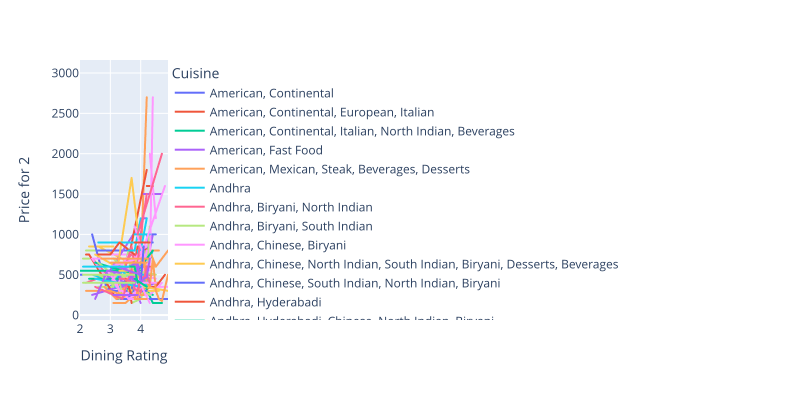

In [144]:
fig = px.line(price_rating_df, y="Price for 2", x="Dining Rating",color='Cuisine')
fig.update_layout(
    width=800,
    height=400)
fig.show()

## Q9) Is there a relation between Region and Price

In [62]:
 region_price_df = zomato_df.groupby(['Location'])['Price for 2'].mean().reset_index() 
region_price_df

,Location,Price for 2
0,Abhiramapuram,200.000000
1,Adambakkam,412.500000
2,Adyar,605.882353
3,Akkarai,637.500000
4,Alandur,620.000000
...,...,...
137,Vepery,406.250000
138,Vettuvankeni,650.000000
139,Virugambakkam,533.333333
140,Washermenpet,616.666667


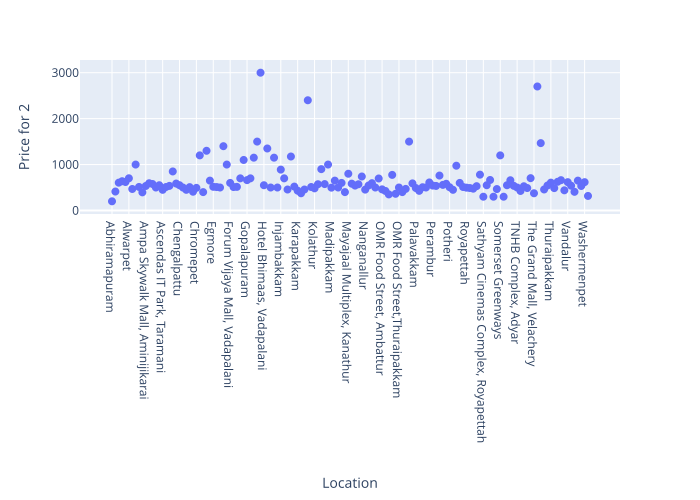

In [63]:
fig = px.scatter(region_price_df, x="Location", y="Price for 2").update_traces(marker_size=8) 
fig.show() 

## Q10) Find the list of Affordable Restaurants?

### The criteria for Affordable Restaurants would be:
#### 1) Low Price
#### 2) 2) High Rated
#### First step will be to find the restaurants with average cost 1/4th the average cost of most expensive restaurant in our dataframe.
 #### Let me explain:-The most expensive restaurant has an average meal cost= 6000. We'll try to stay economical and only pick the
 #### restaurants that are 1/4th of 6000

In [65]:
max_price = zomato_df['Price for 2'].max() 
one_fourth_price = max_price/4 
one_fourth_price 

750.0

 ## Finding list of restaurants that have price less than and equal to 1/4th of the max price i.e Finding Cheap Restauran

In [67]:
zomato_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500,4.3,1500,4.3,9306,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000,4.4,3059,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500,4.3,1361,4.4,10500,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",Zinger Burger,500,4.0,1101,4.0,11200,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450,4.2,617,4.1,22400,"Home Delivery, Indoor Seating"


In [68]:
aff_rest_df = zomato_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location']] 
aff_rest_df = aff_rest_df[aff_rest_df['Price for 2'] <= 1250] 
aff_rest_df.sort_values(by='Price for 2', inplace=True) 
aff_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location
2151,Cane 4 U,100,Beverages,Besant Nagar
754,90ML,100,"Tea, Coffee",Nungambakkam
108,Rayar's Mess,100,South Indian,Mylapore
1001,Snow Cube,150,"Ice Cream, Desserts, Fast Food",Madipakkam
627,Time Passs,150,"Street Food, North Indian, Fast Food",Karapakkam
...,...,...,...,...
213,Tuscana Pizzeria,1200,"Italian, Pizza",Nungambakkam
174,Delhi Highway,1200,"North Indian, Street Food",Nungambakkam
316,Prive Restaurant,1200,"North Indian, Continental, Mexican, Chinese...",Mylapore
17,Abid's,1200,"Seafood, Biryani, Hyderabadi, Arabian, Nor...",Chetpet


In [69]:
 # Finding the highest rated list of restaurants 
 
highrate_rest_df = zomato_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location', 'Dining Rating']] 
highrate_rest_df = highrate_rest_df[highrate_rest_df['Dining Rating'] >= 4.5] 
highrate_rest_df.sort_values(by='Dining Rating', inplace=True) 
highrate_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location,Dining Rating
115,North East Kitchen,450,"Chinese, Konkan, Momos",Egmore,4.5
214,Sera - The Tapas Bar & Restaurant,1600,"Finger Food, Seafood, Italian, Continental",Gopalapuram,4.5
209,Cream Stone,350,"Desserts, Ice Cream",Alwarpet,4.5
207,Va Pho - Asian Canteen,1400,"Asian, Chinese, Beverages",Gopalapuram,4.5
270,ID,300,South Indian,"Sathyam Cinemas Complex, Royapettah",4.5
9367,Cream Stone,350,"Desserts, Ice Cream",Thuraipakkam,4.5
284,Absolute Thai,1000,"Thai, Asian",Foodies Kitchen,4.5
289,Kuuraku,1200,Japanese,Vadapalani,4.5
158,BurgerMan,450,"Burger, Fast Food, Beverages",Besant Nagar,4.5
471,Shmoozie's Hand-Crafted Ice Creams,400,"Ice Cream, Desserts",Egmore,4.5


## Q10) Find the list of most Reliable Restaurants?
### The criteria for most Reliable Restaurants would be:
#### 1) Low Price 
#### 2) High Rated 
#### 3) Large No. of Votes
#### First step will be to find the restaurants with Votes greater than Mean of Votes

In [71]:
 mean_votes = zomato_df['Dining Rating Count'].mean() 
mean_votes 

378.39809296781885

## Finding list of restaurants that have Votes greater than and equal to  Mean of Vote 

In [73]:
mean_rest_df = zomato_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location', 'Dining Rating Count']] 
mean_rest_df = mean_rest_df[mean_rest_df['Dining Rating Count'] > 177] 
mean_rest_df.sort_values(by='Dining Rating Count', inplace=True) 
mean_rest_df 

,Name of Restaurant,Price for 2,Cuisine,Location,Dining Rating Count
9053,A2B - Adyar Ananda Bhavan,300,"Mithai, Street Food, Fast Food, Ice Cream",Perambur,178
9563,The Noodle Theory,400,"Chinese, Fast Food",Adyar,179
9394,The Cascade,1000,"Seafood, Chinese, Asian, Thai, Momos",Mogappair,179
10013,Namma Veedu Vasanta Bhavan,600,"Chinese, South Indian, North Indian",Maduravoyal,179
9519,Wangs Kitchen,800,"Asian, Chinese, Momos",Nandanam,180
...,...,...,...,...,...
9040,Palmshore,1000,"North Indian, Chinese, Arabian, BBQ, Birya...",Ashok Nagar,4478
9038,Palmshore,1000,"North Indian, Chinese, Arabian, BBQ, Birya...",Ramapuram,4805
9026,Copper Kitchen,1000,"North Indian, Chinese, Chettinad, Seafood",Porur,5073
9030,Paradise Biryani,800,"Biryani, North Indian, Chinese",Perungudi,5317


#### These are the most reliable, highest rated and affordable restaurants: We obtain this dataframe by simply taking the intersection of highrate_aff_df & mean_rest_df This dataframe obtained below shows the restaurants whose: Cost is below 1250 Rating is above 4.5 Votes are above 177

In [75]:
 reliable_rest_df = pd.merge(mean_rest_df, highrate_rest_df, how='inner', on=['Name of Restaurant', 'Location']) 
reliable_rest_df = reliable_rest_df[['Name of Restaurant', 'Price for 2_x', 'Cuisine_x', 'Location']] 
reliable_rest_df.rename(columns={'Name of Restaurant':'Name of Restaurant', 'Price for 2_x':'Price for 2', 'Cuisine_x':'Cuisine',  
                                'Location':'Location'},inplace=True)

In [76]:
reliable_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location
0,Shmoozie's Hand-Crafted Ice Creams,400,"Ice Cream, Desserts",Egmore
1,Kuuraku,1200,Japanese,Vadapalani
2,Bombay Kulfi,200,Ice Cream,Anna Nagar East
3,Wok Monk,1200,"Asian, Chinese, Middle Eastern",Anna Nagar West
4,Little Italy,1500,"Italian, Mexican, Salad",Anna Nagar West
5,Blind Ch3mistry,700,"Cafe, Continental, Italian, Desserts, Beve...",Teynampet
6,Writer's Cafe,600,"Cafe, American",Taramani
7,Bombay Kulfi,200,Ice Cream,Adyar
8,The Sandwich Shop,300,"Sandwich, Fast Food, Beverages",West Mambalam
9,Fruit Shop On Greams Road,350,"Beverages, Fast Food, Healthy Food, Juices",Thousand Lights
